# Домашняя работа: NLP Transformer с нуля на PyTorch

В этой домашней работе вы реализуете основные компоненты Transformer для обработки текста:

- character-level токенизацию;
- token embeddings;
- positional embeddings;
- scaled dot-product attention;
- multi-head self-attention;
- causal mask;
- Transformer block;
- decoder-only MiniGPT;
- генерацию текста.

In [69]:
import math
import random
from dataclasses import dataclass
from IPython.display import display, HTML
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("DEVICE:", DEVICE)

torch.manual_seed(42)
random.seed(42)

DEVICE: cpu


## 1. Данные

Ниже есть предзаполненный text, на котором можно обучать трансформер, однако, будет гораздо интереснее, если используете свой текст
Модель будет учиться предсказывать следующий символ.

In [70]:
# Взял текст из книги "Сказать жизни да!", автор - Виктор Франкл

text = """
It is terrible to know that at every moment I bear responsibility for the next; that every decision, from the smallest to the largest, is a decision 'for all eternity'; that in every moment I can actualize the possibility of that particular moment or forfeit it. Every single moment contains thousands of possibilities-and I can only choose one of them to actualize it.

To say yes to life is not only meaningful under all circumstances-because life itself is-but it is also possible under all circumstances.

In the course of life human beings must be prepared to change the direction of this fulfillment of meaning, often abruptly, according to the particular 'challenges of the hour.' The meaning of life can only be a specific one, specific both in relation to each individual person and in relation to each individual hour: the question that life asks us changes both from person to person, and from situation to situation.

For, let us ask ourselves, honestly and seriously, whether we would want to erase the sad experiences from our past, perhaps from our love lives, whether we would want to miss out on everything that was painful or pain inducing-then we would surely all say no. Somehow we know how much we were able to grow and mature precisely during these joyless periods of our existence.

What leads us forward and helps us along the way, what has guided and is guiding us, is a joy in taking responsibility.

Even when times are hard, life does not cease to be meaningful. Just because the meaning of the moment is a painful one, that does not make it any less meaningful. In fact, suffering can be one of the greatest achievements of a human being, provided that the suffering is unavoidable. Where it is possible to change a situation, we must do everything we can to change it. But where suffering is inevitable, we are still able to choose our attitude toward it. This inner attitude is the last of the human freedoms.

Consider the example of a person who is facing a serious illness. They cannot change the diagnosis, but they can change how they face it. They can decide to meet their fate with courage and dignity. They can still fill the time that remains with meaning-by loving others, by finding beauty in small things, or simply by bearing their cross with patience. In this way, even the sufferer can say yes to life.

Life is not primarily a quest for pleasure, or for power, but a quest for meaning. The greatest task for any person is to find the meaning of their own life. This meaning is unique and specific. It can only be fulfilled by that person alone. No one else can take their place. And each moment presents a new challenge. It asks us a question. We must answer not with words, but with our actions and our attitude.

Therefore, we should not ask what we can expect from life. We must rather ask what life expects from us. Life is constantly expecting something from us. It expects us to act, to respond, to take a stand. And each person's answer must be their own.

We who lived in concentration camps can remember the men who walked through the huts comforting others, giving away their last piece of bread. They may have been few in number, but they offer sufficient proof that everything can be taken from a person but one thing: the last of the human freedoms-to choose one's attitude in any given set of circumstances, to choose one's own way.

And there were always choices to make. Every day, every hour, offered the opportunity to make a decision, a decision which determined whether you would or would not submit to those powers which threatened to rob you of your very self, your inner freedom. It is this spiritual freedom-which cannot be taken away-that makes life meaningful and purposeful.

So let us try to live every day as if it were our second chance. As if we had made a mistake yesterday, and today we have been given the opportunity to correct it. In this way, we will feel a deep sense of responsibility for each moment. We will not waste time. We will strive to do the right thing, to love, to forgive, and to find the unique meaning that only this hour offers.

What does an ordinary person do when faced with a fate that seems unbearable? The answer is: they bear it. And in bearing it, they transform it. The German poet Goethe once said: "There is no predicament which cannot be ennobled either by an achievement or by endurance." Either we change our fate, if possible, or we willingly accept it, if necessary. Both paths can lead to meaning. Both paths can lead to a full and rich existence.

I remember a patient of mine, a general practitioner, who fell into a deep depression after the death of his wife. He loved her more than anything in the world, and now he felt that his life was over. I did not try to console him with empty words. Instead, I asked him a simple question: "What would have happened if you had died first, and your wife had survived you?" He looked at me and said: "Oh, that would have been terrible for her. She would have suffered so much." Then I said to him: "You see, doctor, you have spared her this suffering. You have taken it upon yourself so that she did not have to endure it." He said nothing, but he shook my hand and walked out of my office. His suffering now had a meaning. He was not just a victim of fate. He was a protector of his beloved wife, even in death.

This is the power of meaning. It can transform a tragedy into a triumph. It can turn a personal disaster into a human achievement. It is not that we should seek suffering. No. But when suffering is unavoidable, we can still find meaning in how we face it.

Suffering is like a gas. If you put a certain amount of gas into an empty chamber, it will fill the chamber completely, no matter how large or small the chamber is. In the same way, suffering fills the human soul completely, no matter whether the suffering is great or small. The size of the suffering is not important. What matters is how we relate to it. A small slight can cause as much inner pain as a great tragedy, depending on the person. And a great tragedy can be borne with such dignity that it becomes a source of inner strength.

The great lesson that I learned in the concentration camps is this: everything can be taken from a person but one thing. The last of the human freedoms is to choose one's attitude in any given set of circumstances. This freedom cannot be taken away. It is the ultimate freedom. It is what makes us human. It is what allows us to say yes to life, in spite of everything.

There is a famous saying by Nietzsche: "He who has a why to live for can bear almost any how." This is the foundation of logotherapy, the school of thought that I founded. The task of the therapist is not to tell the patient what the meaning of their life is. No one can do that for another person. The task is rather to help the patient see that their life does have a meaning, and that they are capable of finding it. The meaning is out there, waiting to be discovered. It is not something we invent. It is something we find.

And the search for meaning is not always easy. Sometimes it requires great courage. Sometimes it requires great patience. Sometimes it requires simply that we endure. But the search itself is meaningful. The act of seeking is already an answer to the question that life asks us.

Let me tell you about another patient. This one was a young man who had lost his leg in an accident. He was bitter and angry. He felt that his life was over. He refused to leave his room. He refused to see his friends. He refused to do anything but sit and stare at the wall. His parents brought him to me, hoping that I could help him. I sat with him for several sessions, but he would not speak. Finally, I asked him a question: "What can you still do?" He looked at me with surprise. No one had ever asked him that. He thought for a long time, and then he said: "I can still read. I can still think. I can still listen to music. I can still love my family." And slowly, slowly, he began to rebuild his life. He did not get his leg back. But he found meaning in what he still had. And that meaning gave him the strength to go on.

So I say to you: do not despair. Do not give up. Life is waiting for you to answer its call. The call is different for every person, and it changes from moment to moment. But the call is always there. It is never silent. And as long as we are alive, we have the ability to respond. That response is our responsibility. And that responsibility is the source of our dignity and our joy.

We must be careful not to measure the meaning of a life by its outward success or failure. A person can fail in the eyes of the world and still have lived a deeply meaningful life. A person can succeed in every outward way and still feel empty inside. The meaning is not in the outcome. The meaning is in the intention. The meaning is in the attempt. The meaning is in the attitude with which we face our fate.

I think of the many people I met in the camps who faced their death with great dignity. They were not successful by any normal measure. They were starving, sick, and beaten. But in their final moments, they showed a nobility that I have rarely seen elsewhere. They said yes to life, even as life was leaving them. They embraced their fate and made it their own. And in doing so, they transformed their suffering into a triumph.

This is what I mean by saying yes to life. It is not a naive optimism that ignores the dark side of existence. It is not a shallow cheerfulness that refuses to see the pain. It is a deep and courageous affirmation of life, in spite of everything. It is a recognition that even in the darkest hour, there is still something to live for. Even in the deepest suffering, there is still a possibility for meaning. And that possibility is always open to us. It is always available. We just have to choose it.

So I encourage you to ask yourself, every day: What does life expect of me today? What is the task that only I can perform? What is the meaning that only I can fulfill? And then go out and do it. Do it with all your heart. Do it without hesitation. Do it because it is your duty and your joy. And in doing so, you will find that your life has meaning. And that meaning will sustain you, no matter what comes your way.

This, then, is the message of these lectures. Life has meaning under all circumstances. Suffering can be a path to meaning. Love is a path to meaning. And action is a path to meaning. We have the freedom to choose our attitude. We have the responsibility to respond to life's demands. And when we do, we say yes to life. And that yes is the most powerful word we can ever speak.

What we "radiate" into the world, the "waves" that emanate from our being, that is what will remain of us when our being itself has long since passed away. It is never a question of where someone is in life or which profession he is in, it is only a matter of how he fills his place, his circle. Whether a life is fulfilled doesn't depend on how great one's range of action is, but rather only on whether the circle is filled out.

A man's last inner freedom cannot be taken away. And it is this spiritual freedom that makes life meaningful and purposeful. So let us try to live each day as if it were our second chance. Let us strive to find the meaning that only this hour offers. And let us say yes to life, in spite of everything.

this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
this text is repeated to help the model learn patterns.
"""

text = text.lower()
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

print("Text length:", len(text))
print("Vocab size:", vocab_size)
print("Vocabulary:", "".join(chars))

Text length: 11736
Vocab size: 36
Vocabulary: 
 "',-.:;?abcdefghijklmnopqrstuvwxyz


## 2. Кодирование и декодирование текста

### Задание 1

Реализуйте функции:

- `encode(s)` — переводит строку в список индексов;
- `decode(ids)` — переводит список индексов обратно в строку.

In [71]:
def encode(s: str) -> list[int]:
    # TODO: верните список индексов символов через stoi
    return [stoi[ch] for ch in s]


def decode(ids: list[int]) -> str:
    # TODO: верните строку по списку индексов через itos
    return "".join(itos[id] for id in ids)

In [72]:
sample = "attention"
ids = encode(sample)
assert isinstance(ids, list)
assert all(isinstance(i, int) for i in ids)
assert decode(ids) == sample
print("Encoding/decoding tests passed")

Encoding/decoding tests passed


## 3. Train/validation split

In [73]:
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

Train tokens: 10562
Val tokens: 1174


## 4. Создание batch

Для каждого входного токена - нам нужно предсказать следующий токен нашей последовательности.

```text
x = [t, r, a, n]
y = [r, a, n, s]
```


### Реализуйте функцию `get_batch`.

In [74]:
block_size = 32
batch_size = 16


def get_batch(split: str):
    source = train_data if split == "train" else val_data
    ############################################################################
    # TODO:
    # 1. Случайно выберите batch_size стартовых позиций.
    # 2. Для каждой позиции возьмите block_size токенов в x.
    # 3. Для y возьмите те же токены, но сдвинутые на 1 вправо.
    # 4. Перенесите x и y на DEVICE.
    ###########################################################################

    ix = torch.randint(0, len(source) - block_size, (batch_size,))
    x = torch.stack([source[i : i + block_size] for i in ix])
    y = torch.stack([source[i + 1 : i + block_size + 1] for i in ix])

    return x, y

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

In [75]:
x, y = get_batch("train")
assert x.shape == (batch_size, block_size)
assert y.shape == (batch_size, block_size)
assert x.device.type == torch.device(DEVICE).type
assert y.device.type == torch.device(DEVICE).type
print("Batch tests passed")

Batch tests passed


## 5. Scaled Dot-Product Attention

Attention вычисляет, насколько каждый токен должен смотреть на другие токены.

$$Attention(Q, K, V) = softmax(
{QK^T}/{\sqrt{d_k}}
)V$$

###  Реализуйте функцию `scaled_dot_product_attention`.

In [76]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    q, k, v: [B, H, T, D]
    mask: [T, T] или None
    """
    ############################################################################
    # TODO:
    # 1. scores = q @ k^T / sqrt(D)
    # 2. если mask не None, запретите смотреть в masked-позиции
    # 3. softmax по последней размерности
    # 4. умножьте attention weights на v
    ############################################################################

    D = q.shape[-1]
    scores = q @ k.transpose(-2, -1) / (D**0.5)

    if mask is not None:
        if mask.dim() == 2:
            mask = mask.unsqueeze(0).unsqueeze(0)
        scores = scores.masked_fill(mask == 0, float("-inf"))

    attn_weights = torch.softmax(scores, dim=-1)

    out = attn_weights @ v

    return out, attn_weights

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

In [77]:
B, H, T, D = 2, 4, 8, 16
q = torch.randn(B, H, T, D)
k = torch.randn(B, H, T, D)
v = torch.randn(B, H, T, D)

out, attn = scaled_dot_product_attention(q, k, v)
assert out.shape == (B, H, T, D)
assert attn.shape == (B, H, T, T)
assert torch.allclose(attn.sum(dim=-1), torch.ones(B, H, T), atol=1e-5)
print("Scaled attention tests passed")

Scaled attention tests passed


## 6. Causal mask

В NLP модель должна предсказывать следующий токен, опираясь только на уже известные предыдущие токены. Если разрешить ей на будущие позиции, она будет использовать информацию из ответа, что делает обучение некорректным и нереалистичным. Поэтому мы вводим causal mask — матрицу, которая для каждой позиции разрешает учитывать только текущие и предыдущие токены, но запрещает доступ к будущим.


### Реализуйте `make_causal_mask`.

In [78]:
def make_causal_mask(seq_len: int, device=None):
    # TODO: верните bool-матрицу [seq_len, seq_len], где True = можно смотреть
    return torch.tril(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool))

In [79]:
mask = make_causal_mask(4)
expected = torch.tensor(
    [
        [1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1],
    ],
    dtype=torch.bool,
)
assert mask.shape == (4, 4)
assert torch.equal(mask.cpu(), expected)
print("Causal mask tests passed")

Causal mask tests passed


## 7. Multi-Head Self-Attention

Реализуйте класс `MultiHeadSelfAttention`.

Класс `MultiHeadSelfAttention` сначала проецирует входные эмбеддинги в три матрицы — запросы (Q), ключи (K) и значения (V) — с помощью линейного слоя, после чего разбивает их на несколько “голов”. Для каждой головы независимо считается scaled dot-product attention, затем результаты объединяются обратно в единое представление и проходят через финальную линейную проекцию, позволяя модели одновременно учитывать разные типы зависимостей между токенами.

In [80]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.last_attention = None

    def forward(self, x, mask=None):
        B, T, C = x.shape
        ############################################################################
        # TODO:
        # 1. получите qkv
        # 2. разделите q, k, v
        # 3. приведите к форме [B, H, T, D]
        # 4. вызовите scaled_dot_product_attention
        # 5. объедините головы обратно в [B, T, C]
        # 6. примените proj и dropout
        # 7. сохраните attention в self.last_attention
        ############################################################################

        qkv = self.qkv(x)

        q, k, v = qkv.chunk(3, dim=-1)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        attn_out, attn_weights = scaled_dot_product_attention(q, k, v, mask)

        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, self.embed_dim)

        out = self.proj(attn_out)
        out = self.dropout(out)

        self.last_attention = attn_weights

        return out

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

In [81]:
mha = MultiHeadSelfAttention(embed_dim=64, num_heads=4)
x_demo = torch.randn(2, 10, 64)
mask_demo = make_causal_mask(10)
out = mha(x_demo, mask_demo)
assert out.shape == (2, 10, 64)
assert mha.last_attention is not None
assert mha.last_attention.shape == (2, 4, 10, 10)
print("Multi-head attention tests passed")

Multi-head attention tests passed


## 8. Feed Forward Network

### Реализуйте `FeedForward`.

In [82]:
class FeedForward(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        ############################################################################
        # TODO: nn.Sequential: Linear -> GELU -> Linear -> Dropout
        ############################################################################

        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

    def forward(self, x):
        return self.net(x)

In [83]:
ff = FeedForward(embed_dim=64, hidden_dim=256)
x_demo = torch.randn(2, 10, 64)
out = ff(x_demo)
assert out.shape == (2, 10, 64)
print("FeedForward tests passed")

FeedForward tests passed


## 9. Transformer Block

Используем Pre-LN вариант:

```python
x = x + attention(layer_norm(x))
x = x + mlp(layer_norm(x))
```

### Реализуйте `TransformerBlock`.


In [84]:
class TransformerBlock(nn.Module):
    def __init__(
        self, embed_dim: int, num_heads: int, mlp_ratio: int = 4, dropout: float = 0.1
    ):
        super().__init__()
        ############################################################################
        # TODO: ln1, attn, ln2, ff
        ############################################################################

        hidden_dim = int(embed_dim * mlp_ratio)

        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = FeedForward(embed_dim, hidden_dim, dropout)

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

    def forward(self, x, mask=None):
        x = x + self.attn(self.ln1(x), mask=mask)
        x = x + self.ff(self.ln2(x))
        return x

In [85]:
block = TransformerBlock(embed_dim=64, num_heads=4)
x_demo = torch.randn(2, 10, 64)
mask_demo = make_causal_mask(10)
out = block(x_demo, mask_demo)
assert out.shape == (2, 10, 64)
print("TransformerBlock tests passed")

TransformerBlock tests passed


## 10. Конфигурация модели

In [86]:
@dataclass
class TransformerConfig:
    vocab_size: int
    block_size: int = 16
    embed_dim: int = 64
    num_heads: int = 4
    depth: int = 2
    dropout: float = 0.1

## 11. MiniGPT / Decoder-only Transformer

### Реализуйте класс `MiniGPT`.

In [87]:
class MiniGPT(nn.Module):
    def __init__(self, config: TransformerConfig):
        super().__init__()
        self.config = config
        self.token_embedding = nn.Embedding(config.vocab_size, config.embed_dim)
        self.position_embedding = nn.Embedding(config.block_size, config.embed_dim)
        self.dropout = nn.Dropout(config.dropout)

        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    embed_dim=config.embed_dim,
                    num_heads=config.num_heads,
                    mlp_ratio=4,
                    dropout=config.dropout,
                )
                for _ in range(config.depth)
            ]
        )

        self.ln_f = nn.LayerNorm(config.embed_dim)
        self.lm_head = nn.Linear(config.embed_dim, config.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.config.block_size
        ############################################################################
        # TODO:
        # 1. token embeddings
        # 2. positional embeddings
        # 3. сложить embeddings
        # 4. causal mask
        # 5. Transformer blocks
        # 6. logits
        # 7. loss, если targets is not None
        ############################################################################

        token_emb = self.token_embedding(idx)

        positions = torch.arange(0, T, device=idx.device).unsqueeze(0)
        pos_emb = self.position_embedding(positions)

        x = self.dropout(token_emb + pos_emb)

        mask = make_causal_mask(T, device=idx.device)

        for block in self.blocks:
            x = block(x, mask=mask)

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            logits_flat = logits.view(B * T, -1)
            targets_flat = targets.view(B * T)
            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

        ############################################################################
        #                             END OF YOUR CODE                             #
        ############################################################################

    @torch.no_grad()
    def generate(self, idx, max_new_tokens: int, temperature: float = 1.0):
        """
        idx: [B, T]
        """
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.block_size :]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_idx], dim=1)

        return idx

In [88]:
config = TransformerConfig(
    vocab_size=vocab_size,
    block_size=32,
    embed_dim=64,
    num_heads=4,
    depth=2,
    dropout=0.1,
)
model = MiniGPT(config).to(DEVICE)
x, y = get_batch("train")
logits, loss = model(x, y)
assert logits.shape == (batch_size, block_size, vocab_size)
assert loss is not None and loss.ndim == 0
start = torch.zeros((1, 1), dtype=torch.long, device=DEVICE)
generated = model.generate(start, max_new_tokens=10)
assert generated.shape == (1, 11)
print("MiniGPT tests passed")
print("Parameters:", sum(p.numel() for p in model.parameters()))

MiniGPT tests passed
Parameters: 106788


## 12. Оценка loss

### Реализуйте `estimate_loss`.

In [89]:
@torch.no_grad()
def estimate_loss(model, eval_iters: int = 20):
    model.eval()
    results = {}
    ############################################################################
    # TODO: посчитайте средний loss для train и val
    ############################################################################

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()

        results[split] = losses.mean().item()

    model.train()

    return results

    ############################################################################
    #                             END OF YOUR CODE                             #
    ############################################################################

In [90]:
losses = estimate_loss(model, eval_iters=2)
assert "train" in losses and "val" in losses
assert isinstance(losses["train"], float)
assert isinstance(losses["val"], float)
print("Estimate loss tests passed:", losses)

Estimate loss tests passed: {'train': 3.775984048843384, 'val': 3.8134002685546875}


## 13. Training loop

Поставьте `RUN_TRAINING=True`, когда все TODO реализованы.

In [91]:
config = TransformerConfig(
    vocab_size=vocab_size,
    block_size=32,
    embed_dim=128,
    num_heads=4,
    depth=4,
    dropout=0.1,
)
model = MiniGPT(config).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

max_iters = 1000
eval_interval = 100
loss_history = []

for step in range(max_iters):
    if step % eval_interval == 0:
        losses = estimate_loss(model, eval_iters=20)
        print(
            f"step {step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}"
        )

    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
print("Training finished")

step 0: train loss 3.7658, val loss 3.7799
step 100: train loss 2.3766, val loss 2.4080
step 200: train loss 2.2692, val loss 2.3203
step 300: train loss 2.1872, val loss 2.2657
step 400: train loss 2.0944, val loss 2.2016
step 500: train loss 1.9894, val loss 2.1341
step 600: train loss 1.8724, val loss 2.0470
step 700: train loss 1.7957, val loss 1.9997
step 800: train loss 1.7089, val loss 1.9023
step 900: train loss 1.6142, val loss 1.9302
Training finished


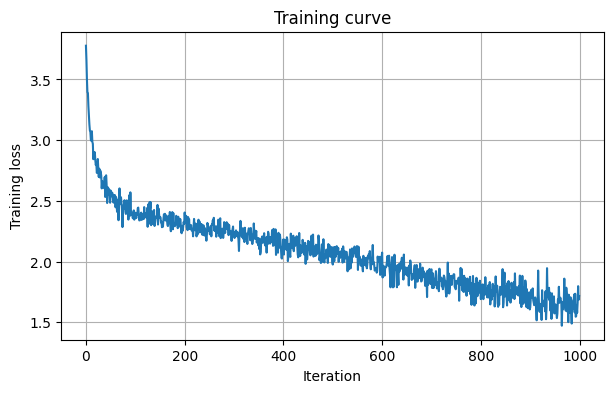

In [92]:
if loss_history:
    plt.figure(figsize=(7, 4))
    plt.plot(loss_history)
    plt.xlabel("Iteration")
    plt.ylabel("Training loss")
    plt.title("Training curve")
    plt.grid(True)
    plt.show()

## 14. Генерация текста

In [93]:
model.eval()
prompt = "the meaning of life is"
idx = torch.tensor([encode(prompt)], dtype=torch.long, device=DEVICE)
out = model.generate(idx, max_new_tokens=300, temperature=0.8)
print(decode(out[0].tolist()))

the meaning of life is as is. is is ust their is nect. thin the cast hom now lignigh in wevethery the life it the orsut the can tre meaning. the is to no. is cose siomstion, to fithim to meaning the the no cave to leestion. wi stiing to change mean is it to thewat is the in any ding, ho it the searked it. no he indov the


## 15. Визуализация "the meaning of life is"

In [97]:
def visualize_attention(
    model: MiniGPT, input_text: str, layer_id: int = -1, head_id: int = 0
):
    model.eval()

    idx = torch.tensor([encode(input_text)], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        _ = model(idx)

    block = model.blocks[layer_id]
    attn = block.attn.last_attention

    assert attn is not None
    assert 0 <= head_id < attn.shape[1]

    attn_map = attn[0, head_id].detach().cpu()  # [T, T]
    tokens = list(input_text)

    plt.figure(figsize=(7, 6))
    plt.imshow(attn_map, cmap="viridis")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(f"'the meaning of life is' heatmap: layer={layer_id}, head={head_id}")

    plt.xticks(range(len(tokens)), tokens)
    plt.yticks(range(len(tokens)), tokens)

    plt.xlabel("Key / previous tokens")
    plt.ylabel("Query / current token")
    plt.tight_layout()
    plt.show()

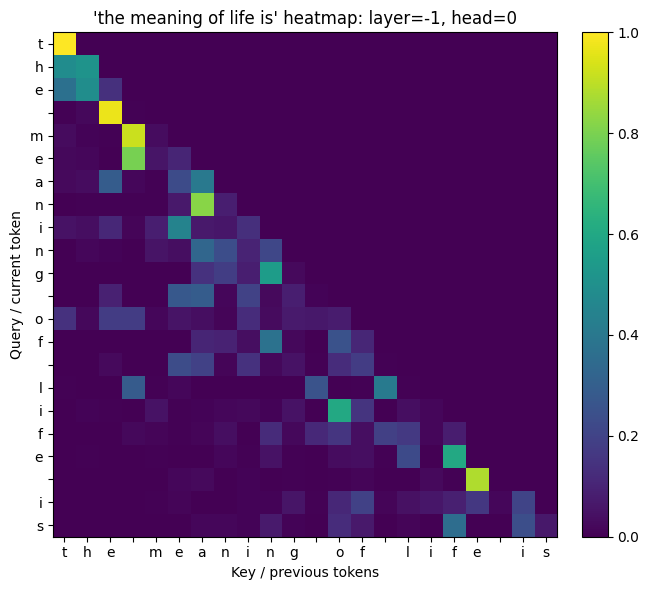

In [95]:
visualize_attention(model, "the meaning of life is", layer_id=-1, head_id=0)

## 16. Теоретическая часть

1. Почему attention делят на `sqrt(d_k)`?

    **Ответ**:
    Чтобы предотвратить слишком маленькие градиенты при больших размерностях d_k.

2. Чем decoder-only Transformer отличается от encoder-only Transformer?

    **Ответ**:
    Decoder-only использует causal (нижнетреугольную) маску, которая запрещает токену "видеть" будущие позиции. Это позволяет генерировать текст авторегрессивно: предсказывать следующий токен на основе предыдущих. Примеры: GPT, LLaMA.

    Encoder-only использует бидирекциональное внимание (полный контекст), где каждый токен видит все    остальные токены в последовательности. Это позволяет решать задачи понимания, но не генерации:     классификация текста, извлечение именованных сущностей, ответы на вопросы по заданному контексту.   Пример: BERT.

    Также decoder-only модели обучаются на задаче causal language modeling (предсказание следующего     токена), а encoder-only — на masked language modeling (восстановление случайно скрытых токенов).

3. Что будет, если убрать residual connections?

    **Ответ**:
    Сеть практически перестанет обучаться глубоко.

    - Градиенты будут затухать при проходе через множество слоёв

    - Потеря информации: будет невозможно обучить >10 слоёв

    - Деградация: добавление слоёв будет ухудшать качество вместо улучшения

4. Почему маленькая модель на маленьком тексте быстро переобучается?

    **Ответ**:
    Основная причина — несоответствие между ёмкостью модели и объёмом обучающих данных. Маленькая модель    на маленьком тексте переобучается по следующим причинам:

    - Низкое разнообразие данных

    - Достаточная ёмкость

    - Отсутствие регуляризации

    В результате модель вместо изучения закономерностей языка просто выучивает обучающую выборку наизусть и не способна обобщаться на новые примеры. Решения: увеличить датасет, усилить регуляризацию, уменьшить число параметров или использовать early stopping.


## Оценка модели

Perplexity — информативная метрика для языковых моделей, которая отражает уверенность модели в предсказаниях следующего токена. В отличие от accuracy, которая учитывает только точные совпадения, perplexity использует вероятности и "наказывает" модель даже за “почти правильные” ответы, если она не уверена. Кроме того, perplexity имеет понятную интерпретацию: это среднее “количество вариантов”, из которых модель как бы выбирает следующий токен — чем меньше, тем лучше модель понимает текст.

Значения perplexity можно оценить так:
- PPL примерно 1–2 - отлично (почти запомнила)
- PPL примерно 10–50 - нормально
- PPL > 100 - плохо

In [99]:
def perplexity(loss):
    """Perplexity = exp(loss)"""
    return torch.exp(torch.tensor(loss)).item()


@torch.no_grad()
def evaluate_loss_on_text_sampled(model, text, num_batches=50, batch_size=64):
    model.eval()

    data = torch.tensor(encode(text), dtype=torch.long).to(DEVICE)

    max_start = len(data) - block_size - 1
    if max_start <= 0:
        raise ValueError(f"Text is too short: len={len(data)}, block_size={block_size}")

    losses = []

    for _ in range(num_batches):
        ix = torch.randint(0, max_start, (batch_size,), device=DEVICE)

        x = torch.stack([data[i : i + block_size] for i in ix])
        y = torch.stack([data[i + 1 : i + block_size + 1] for i in ix])

        _, loss = model(x, y)
        losses.append(loss.item())

    return sum(losses) / len(losses)


loss = evaluate_loss_on_text_sampled(model, text)
ppl = perplexity(loss)

In [100]:
display(HTML(f"<h1>Оценка Вашей модели: {ppl:.2f}</h1>"))